# Perbandingan Model: Tanpa SMOTE vs Dengan SMOTE
## Analisis Dampak SMOTE terhadap Performa Model Prediksi MDR-TB

**Tujuan:** Membandingkan performa tiga model (Logistic Regression, Decision Tree, SVM) ketika dilatih **tanpa SMOTE** vs **dengan SMOTE** pada dataset MDR-TB.

**SMOTE (Synthetic Minority Over-sampling Technique)** menghasilkan data sintetis untuk kelas minoritas sehingga distribusi kelas menjadi seimbang pada data training.

**Sections:**
1. Setup & Data Loading
2. Training Tanpa SMOTE
3. Training Dengan SMOTE
4. Perbandingan Hasil
5. Visualisasi Perbandingan
6. Kesimpulan & Rekomendasi

In [1]:
# ============================
# 1. Setup & Data Loading
# ============================
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
})
sns.set_style('whitegrid')

PROJECT_ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

from preprocessing import DataPreprocessor
from training import ModelTrainer
from evaluation import ModelEvaluator

# Load data dari MySQL (sumber data yang sama dengan web)
import pymysql

DB_CONFIG = {
    'host': 'localhost',
    'port': 3306,
    'user': 'root',
    'password': 'root',
    'database': 'laravel_mdr',
}

# Column mapping: database (lowercase) -> preprocessor format
COLUMN_MAPPING = {
    'usia': 'Usia',
    'ket_usia': 'Ket.Usia',
    'jenis_kelamin': 'Jenis Kelamin',
    'status_bekerja': 'Status Bekerja',
    'bb': 'BB',
    'tb': 'TB',
    'imt': 'IMT',
    'status_gizi': 'Status Gizi',
    'status_merokok': 'Status Merokok',
    'pemeriksaan_kontak': 'Pemeriksaan Kontak',
    'riwayat_dm': 'Riwayat_DM',
    'riwayat_hiv': 'Riwayat_HIV',
    'komorbiditas': 'Komorbiditas',
    'kepatuhan_minum_obat': 'Kepatuhan Minum Obat',
    'efek_samping_obat': 'Efek Samping Obat',
    'keterangan_efek_samping': 'Keterangan Efek Samping',
    'riwayat_pengobatan': 'Riwayat Pengobatan Sebelumnya',
    'panduan_pengobatan': 'Panduan Pengobatan',
    'keberhasilan_pengobatan': 'Keberhasilan Pengobatan',
}

conn = pymysql.connect(**DB_CONFIG)
query = "SELECT * FROM training_data"
df_raw = pd.read_sql(query, conn)
conn.close()

# Rename columns to match preprocessor format
df_raw = df_raw.rename(columns=COLUMN_MAPPING)

# Drop database-only columns (id, timestamps)
cols_to_drop = [c for c in ['id', 'created_at', 'updated_at'] if c in df_raw.columns]
df_raw = df_raw.drop(columns=cols_to_drop)

# Sesuaikan tipe data BB & TB agar konsisten dengan web
# (PHP/Laravel mengirim BB & TB sebagai integer via JSON,
#  sedangkan pymysql mengembalikan float64 dari MySQL FLOAT column)
df_raw['BB'] = df_raw['BB'].astype(int)
df_raw['TB'] = df_raw['TB'].astype(int)

# Preprocess
preprocessor = DataPreprocessor()
df_processed = preprocessor.preprocess(df_raw)
X, y = preprocessor.get_features_and_target(df_processed)

print(f"Data loaded from MySQL database: laravel_mdr")
print(f"Dataset: {X.shape[0]} sampel, {X.shape[1]} fitur")
print(f"Distribusi kelas:")
print(f"  Kelas 0 (Berhasil): {(y==0).sum()}")
print(f"  Kelas 1 (Tidak Berhasil): {(y==1).sum()}")
print(f"  Rasio Imbalance: {(y==0).sum() / (y==1).sum():.2f}:1")

Feature Engineering: IMT dihitung dari BB dan TB (175 records)
Data loaded from MySQL database: laravel_mdr
Dataset: 151 sampel, 17 fitur
Distribusi kelas:
  Kelas 0 (Berhasil): 105
  Kelas 1 (Tidak Berhasil): 46
  Rasio Imbalance: 2.28:1


## 2. Training Tanpa SMOTE
Model dilatih dengan data asli (imbalanced). Logistic Regression dan SVM sudah menggunakan `class_weight='balanced'` sebagai kompensasi.

In [2]:
# ============================
# 2. Training TANPA SMOTE
# ============================
print("=" * 60)
print("SKENARIO 1: TANPA SMOTE")
print("=" * 60)

trainer_no_smote = ModelTrainer(n_folds=5)
evaluator_no_smote = ModelEvaluator()

results_no_smote = trainer_no_smote.train(X, y, use_smote=False)

X_train_ns = results_no_smote['X_train']
X_test_ns = results_no_smote['X_test']
y_train_ns = results_no_smote['y_train']
y_test_ns = results_no_smote['y_test']

eval_no_smote = evaluator_no_smote.evaluate_all_models(trainer_no_smote.models, X_test_ns, y_test_ns)

print(f"\nTraining set: {len(X_train_ns)} sampel")
print(f"  Kelas 0: {(y_train_ns==0).sum()}, Kelas 1: {(y_train_ns==1).sum()}")
print(f"Test set: {len(X_test_ns)} sampel")

SKENARIO 1: TANPA SMOTE

=== Class Distribution ===
Original dataset: {0: 105, 1: 46} (total: 151)
Training set: {0: 73, 1: 32} (total: 105)
Training set size: 105
Validation set size: 23
Test set size: 23

=== Hyperparameter Tuning ===

Tuning Logistic Regression...


  Best params: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
  Best CV F1: 0.8931

Tuning Decision Tree...


  Best params: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2}
  Best CV F1: 0.8719

Tuning Support Vector Machine...


  Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
  Best CV F1: 0.8560

=== Cross Validation ===

Cross-validating Logistic Regression...
  Accuracy: 0.9333 (+/- 0.0486)
  F1 Score: 0.8931 (+/- 0.0705)

Cross-validating Decision Tree...


  Accuracy: 0.9238 (+/- 0.0486)
  F1 Score: 0.8719 (+/- 0.0850)

Cross-validating Support Vector Machine...
  Accuracy: 0.9238 (+/- 0.0486)
  F1 Score: 0.8560 (+/- 0.1110)

=== Final Training ===
Training Logistic Regression...


Training Decision Tree...
Training Support Vector Machine...

Best model: Logistic Regression (F1: 0.8931)

=== Logistic Regression ===
Accuracy:  0.9130
Precision: 0.8571
Recall:    0.8571
F1 Score:  0.8571
Confusion Matrix: TP=6, TN=15, FP=1, FN=1

=== Decision Tree ===
Accuracy:  0.8696
Precision: 0.8333
Recall:    0.7143
F1 Score:  0.7692
Confusion Matrix: TP=5, TN=15, FP=1, FN=2

=== Support Vector Machine ===
Accuracy:  0.8261
Precision: 0.8000
Recall:    0.5714
F1 Score:  0.6667
Confusion Matrix: TP=4, TN=15, FP=1, FN=3

Training set: 105 sampel
  Kelas 0: 73, Kelas 1: 32
Test set: 23 sampel


## 3. Training Dengan SMOTE
SMOTE diterapkan **hanya pada data training** setelah split. Data testing tetap menggunakan data asli (tidak di-oversample) untuk evaluasi yang fair.

> **Catatan:** Memerlukan library `imbalanced-learn`. Jika belum terinstall: `pip install imbalanced-learn`

In [3]:
# ============================
# 3. Training DENGAN SMOTE
# ============================
print("=" * 60)
print("SKENARIO 2: DENGAN SMOTE")
print("=" * 60)

trainer_smote = ModelTrainer(n_folds=5)
evaluator_smote = ModelEvaluator()

results_smote = trainer_smote.train(X, y, use_smote=True)

X_train_sm = results_smote['X_train']
X_test_sm = results_smote['X_test']
y_train_sm = results_smote['y_train']
y_test_sm = results_smote['y_test']

eval_smote = evaluator_smote.evaluate_all_models(trainer_smote.models, X_test_sm, y_test_sm)

print(f"\nTraining set (setelah SMOTE): {len(X_train_sm)} sampel")
print(f"  Kelas 0: {(y_train_sm==0).sum()}, Kelas 1: {(y_train_sm==1).sum()}")
print(f"Test set: {len(X_test_sm)} sampel (tidak di-oversample)")

SKENARIO 2: DENGAN SMOTE

=== Class Distribution ===
Original dataset: {0: 105, 1: 46} (total: 151)
Training set: {0: 73, 1: 32} (total: 105)
Training set size: 105
Validation set size: 23
Test set size: 23



=== SMOTE Applied ===
Training set after SMOTE: {0: 73, 1: 73} (total: 146)

=== Hyperparameter Tuning ===

Tuning Logistic Regression...


  Best params: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
  Best CV F1: 0.8966

Tuning Decision Tree...


  Best params: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
  Best CV F1: 0.8846

Tuning Support Vector Machine...


  Best params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
  Best CV F1: 0.9019

=== Cross Validation ===

Cross-validating Logistic Regression...
  Accuracy: 0.9041 (+/- 0.0593)
  F1 Score: 0.8966 (+/- 0.0761)

Cross-validating Decision Tree...


  Accuracy: 0.8908 (+/- 0.0759)
  F1 Score: 0.8846 (+/- 0.0823)

Cross-validating Support Vector Machine...


  Accuracy: 0.9037 (+/- 0.0671)
  F1 Score: 0.9019 (+/- 0.0705)

=== Final Training ===
Training Logistic Regression...
Training Decision Tree...
Training Support Vector Machine...

Best model: Support Vector Machine (F1: 0.9019)

=== Logistic Regression ===
Accuracy:  0.8261
Precision: 0.7143
Recall:    0.7143
F1 Score:  0.7143
Confusion Matrix: TP=5, TN=14, FP=2, FN=2

=== Decision Tree ===
Accuracy:  0.6522
Precision: 0.4286
Recall:    0.4286
F1 Score:  0.4286
Confusion Matrix: TP=3, TN=12, FP=4, FN=4

=== Support Vector Machine ===
Accuracy:  0.8261
Precision: 0.7143
Recall:    0.7143
F1 Score:  0.7143
Confusion Matrix: TP=5, TN=14, FP=2, FN=2

Training set (setelah SMOTE): 146 sampel
  Kelas 0: 73, Kelas 1: 73
Test set: 23 sampel (tidak di-oversample)


## 4. Perbandingan Hasil
Tabel perbandingan metrik berdasarkan **Cross-Validation F1-Score** (metrik yang sama dengan yang ditampilkan di web) untuk kedua skenario.

In [4]:
# ============================
# 4. Tabel Perbandingan (Cross-Validation — sama seperti di web)
# ============================
cv_ns = trainer_no_smote.cv_results
cv_sm = trainer_smote.cv_results

cv_metrics_list = ['accuracy', 'precision', 'recall', 'f1']
cv_metric_labels = ['Accuracy', 'Precision', 'Recall (Sensitivity)', 'F1-Score']

rows = []
for model_name in cv_ns.keys():
    for metric, label in zip(cv_metrics_list, cv_metric_labels):
        val_ns = cv_ns[model_name][metric]['mean'] * 100
        std_ns = cv_ns[model_name][metric]['std'] * 100
        val_sm = cv_sm[model_name][metric]['mean'] * 100
        std_sm = cv_sm[model_name][metric]['std'] * 100
        diff = val_sm - val_ns
        rows.append({
            'Model': model_name,
            'Metrik': label,
            'Tanpa SMOTE (%)': f'{val_ns:.2f} (\u00b1{std_ns:.2f})',
            'Dengan SMOTE (%)': f'{val_sm:.2f} (\u00b1{std_sm:.2f})',
            'Selisih (pp)': f'{diff:+.2f}',
            'Lebih Baik': 'SMOTE' if diff > 0.5 else ('Sama' if abs(diff) <= 0.5 else 'Tanpa SMOTE')
        })

comparison_df = pd.DataFrame(rows)

# Tampilkan per model
for model_name in cv_ns.keys():
    print(f"\n{'='*70}")
    print(f"  {model_name}")
    print(f"{'='*70}")
    subset = comparison_df[comparison_df['Model'] == model_name].drop(columns='Model')
    print(subset.to_string(index=False))

# Summary tabel F1
print(f"\n{'='*70}")
print("  RINGKASAN CV F1-SCORE (sama seperti yang ditampilkan di web)")
print(f"{'='*70}")
summary_rows = []
for model_name in cv_ns.keys():
    f1_ns = cv_ns[model_name]['f1']['mean'] * 100
    f1_ns_std = cv_ns[model_name]['f1']['std'] * 100
    f1_sm = cv_sm[model_name]['f1']['mean'] * 100
    f1_sm_std = cv_sm[model_name]['f1']['std'] * 100
    summary_rows.append({
        'Model': model_name,
        'F1 Tanpa SMOTE (%)': f'{f1_ns:.2f} (\u00b1{f1_ns_std:.2f})',
        'F1 Dengan SMOTE (%)': f'{f1_sm:.2f} (\u00b1{f1_sm_std:.2f})',
        'Selisih (pp)': f'{f1_sm - f1_ns:+.2f}'
    })
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

# Tambahan: test set evaluation
print(f"\n{'='*70}")
print("  EVALUASI PADA TEST SET (23 sampel, data baru)")
print(f"{'='*70}")
for model_name in eval_no_smote.keys():
    f1_ns_test = eval_no_smote[model_name]['metrics']['f1_score'] * 100
    f1_sm_test = eval_smote[model_name]['metrics']['f1_score'] * 100
    print(f"  {model_name:30s} Tanpa: {f1_ns_test:.2f}% | Dengan: {f1_sm_test:.2f}%")

summary_df


  Logistic Regression
              Metrik Tanpa SMOTE (%) Dengan SMOTE (%) Selisih (pp)  Lebih Baik
            Accuracy   93.33 (±4.86)    90.41 (±5.93)        -2.92 Tanpa SMOTE
           Precision   88.81 (±9.81)    91.49 (±2.39)        +2.68       SMOTE
Recall (Sensitivity)   90.48 (±7.82)   88.76 (±12.52)        -1.71 Tanpa SMOTE
            F1-Score   89.31 (±7.05)    89.66 (±7.61)        +0.35        Sama

  Decision Tree
              Metrik Tanpa SMOTE (%) Dengan SMOTE (%) Selisih (pp)  Lebih Baik
            Accuracy   92.38 (±4.86)    89.08 (±7.59)        -3.30 Tanpa SMOTE
           Precision  88.93 (±10.62)    90.07 (±6.83)        +1.15       SMOTE
Recall (Sensitivity)  87.14 (±12.38)   87.43 (±11.23)        +0.29        Sama
            F1-Score   87.19 (±8.50)    88.46 (±8.23)        +1.26       SMOTE

  Support Vector Machine
              Metrik Tanpa SMOTE (%) Dengan SMOTE (%) Selisih (pp)  Lebih Baik
            Accuracy   92.38 (±4.86)    90.37 (±6.71)        -2.0

,Model,F1 Tanpa SMOTE (%),F1 Dengan SMOTE (%),Selisih (pp)
0,Logistic Regression,89.31 (±7.05),89.66 (±7.61),+0.35
1,Decision Tree,87.19 (±8.50),88.46 (±8.23),+1.26
2,Support Vector Machine,85.60 (±11.10),90.19 (±7.05),+4.58


## 5. Visualisasi Perbandingan

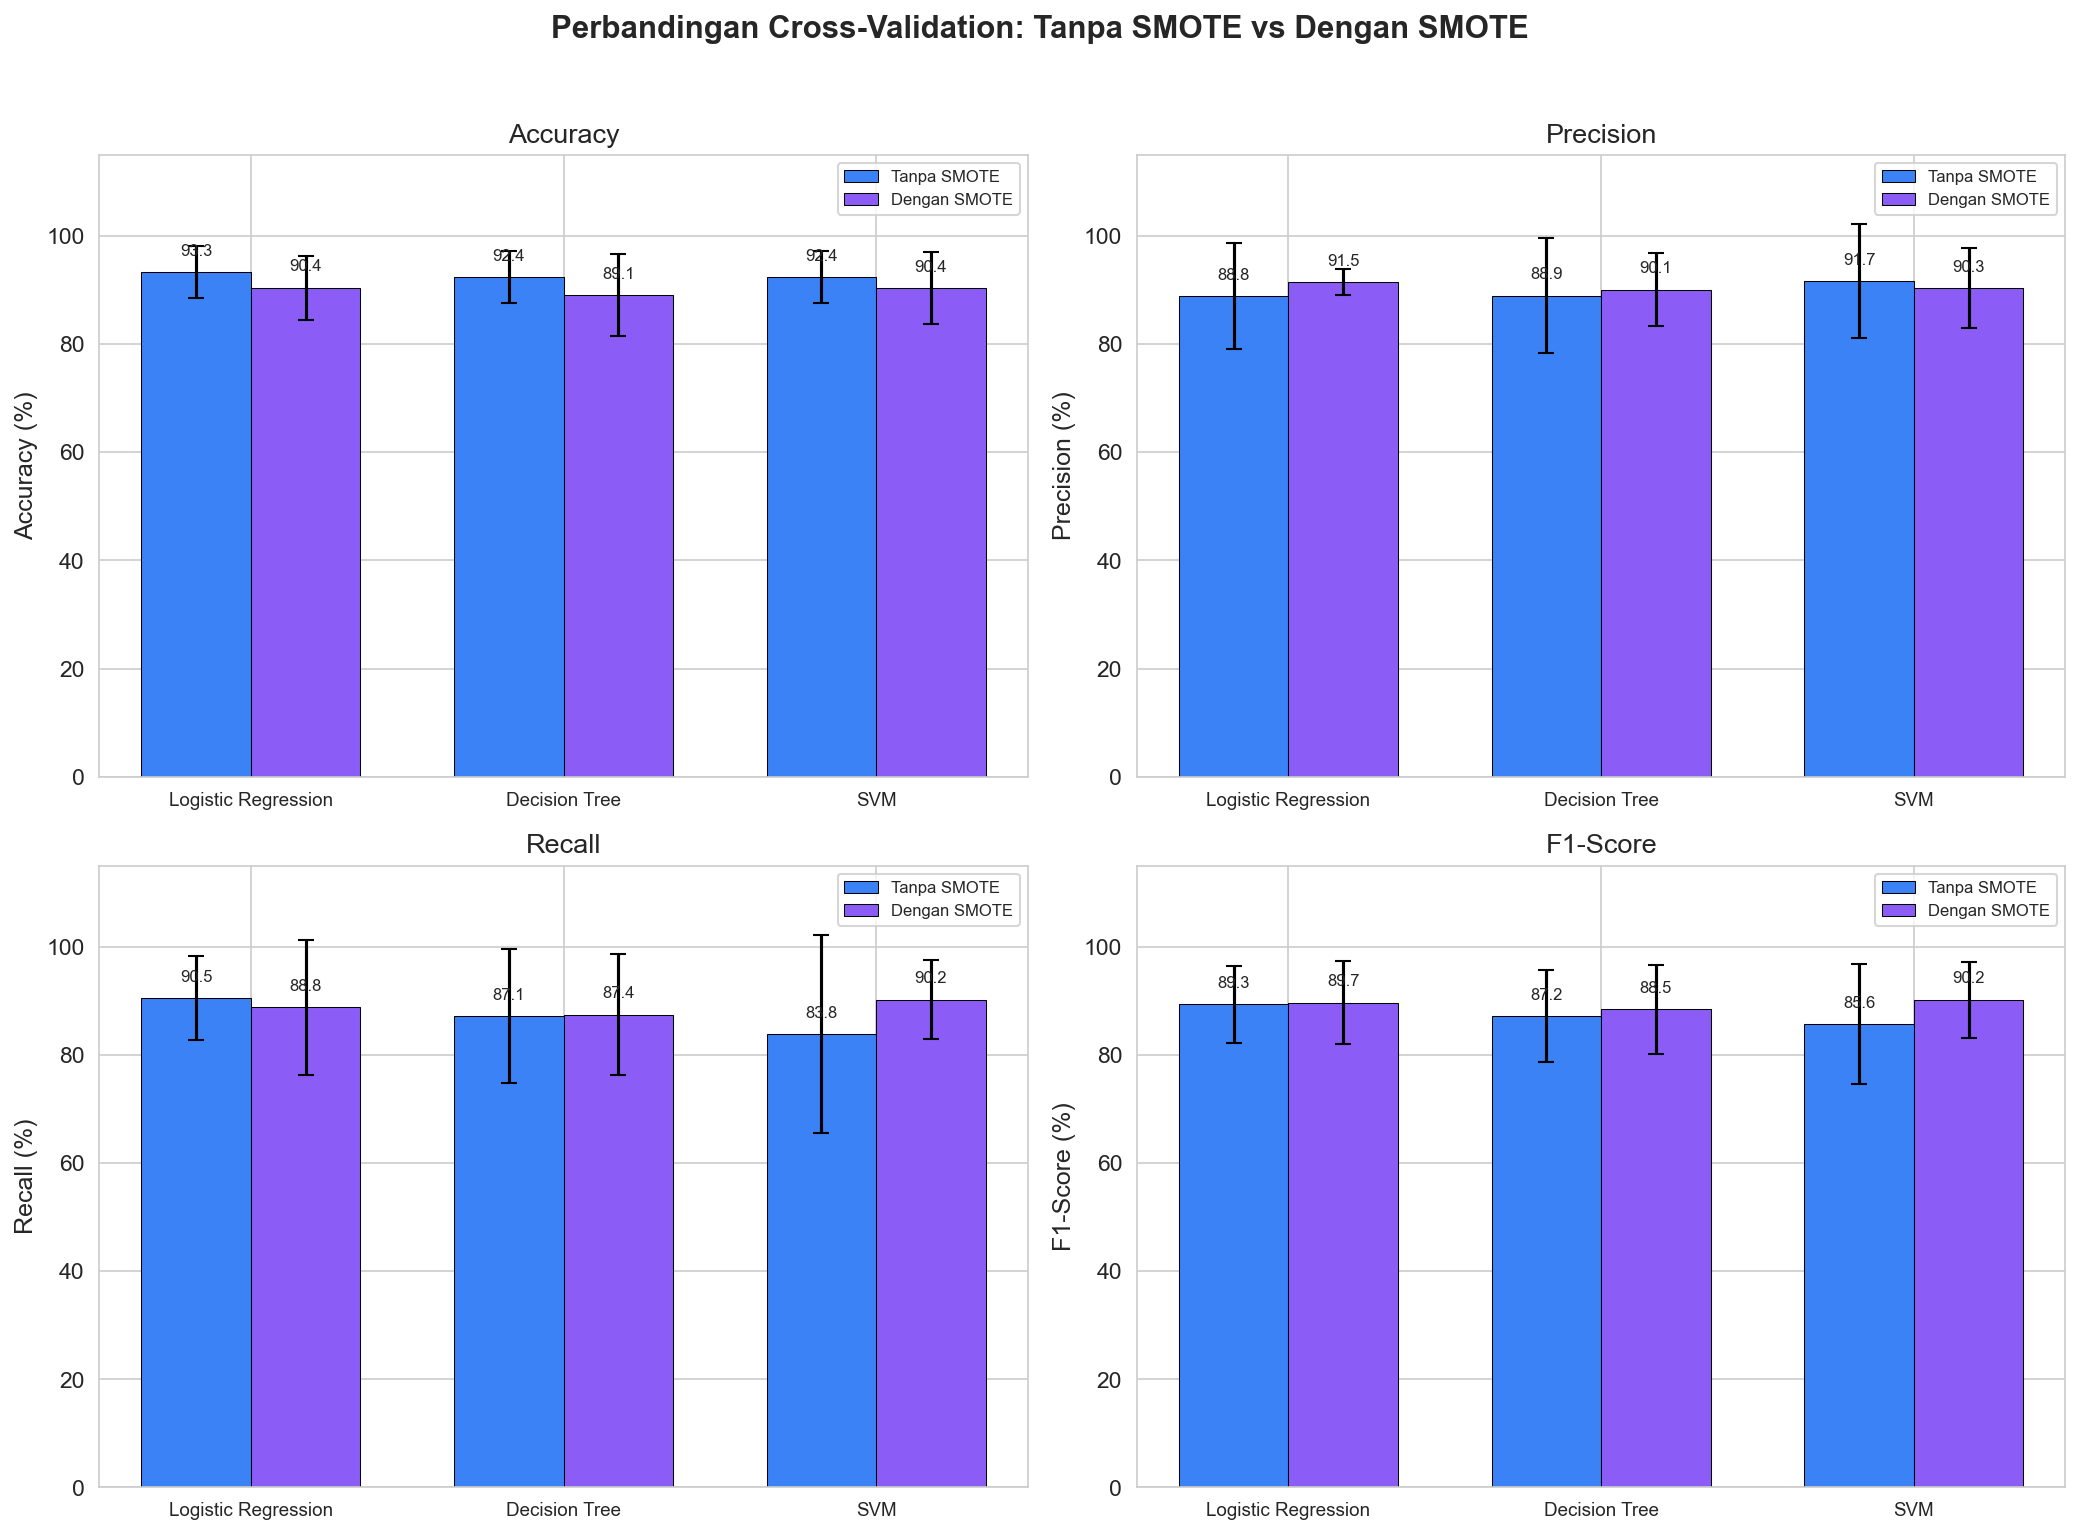

In [5]:
# ============================
# 5a. Bar Chart Perbandingan Metrik per Model (Cross-Validation)
# ============================
model_names = list(cv_ns.keys())
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
metric_titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
bar_width = 0.35
x = np.arange(len(model_names))

for idx, (metric, title) in enumerate(zip(metrics_to_plot, metric_titles)):
    ax = axes[idx // 2][idx % 2]
    vals_ns = [cv_ns[m][metric]['mean'] * 100 for m in model_names]
    stds_ns = [cv_ns[m][metric]['std'] * 100 for m in model_names]
    vals_sm = [cv_sm[m][metric]['mean'] * 100 for m in model_names]
    stds_sm = [cv_sm[m][metric]['std'] * 100 for m in model_names]

    bars1 = ax.bar(x - bar_width/2, vals_ns, bar_width, label='Tanpa SMOTE',
                   color='#3b82f6', edgecolor='black', linewidth=0.5,
                   yerr=stds_ns, capsize=4)
    bars2 = ax.bar(x + bar_width/2, vals_sm, bar_width, label='Dengan SMOTE',
                   color='#8b5cf6', edgecolor='black', linewidth=0.5,
                   yerr=stds_sm, capsize=4)

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2.5,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2.5,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

    ax.set_ylabel(f'{title} (%)')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels([n.replace('Support Vector Machine', 'SVM') for n in model_names], fontsize=9)
    ax.set_ylim(0, 115)
    ax.legend(fontsize=8)

plt.suptitle('Perbandingan Cross-Validation: Tanpa SMOTE vs Dengan SMOTE', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'smote_comparison_metrics.png')
plt.savefig(FIGURES_DIR / 'smote_comparison_metrics.pdf')
plt.show()

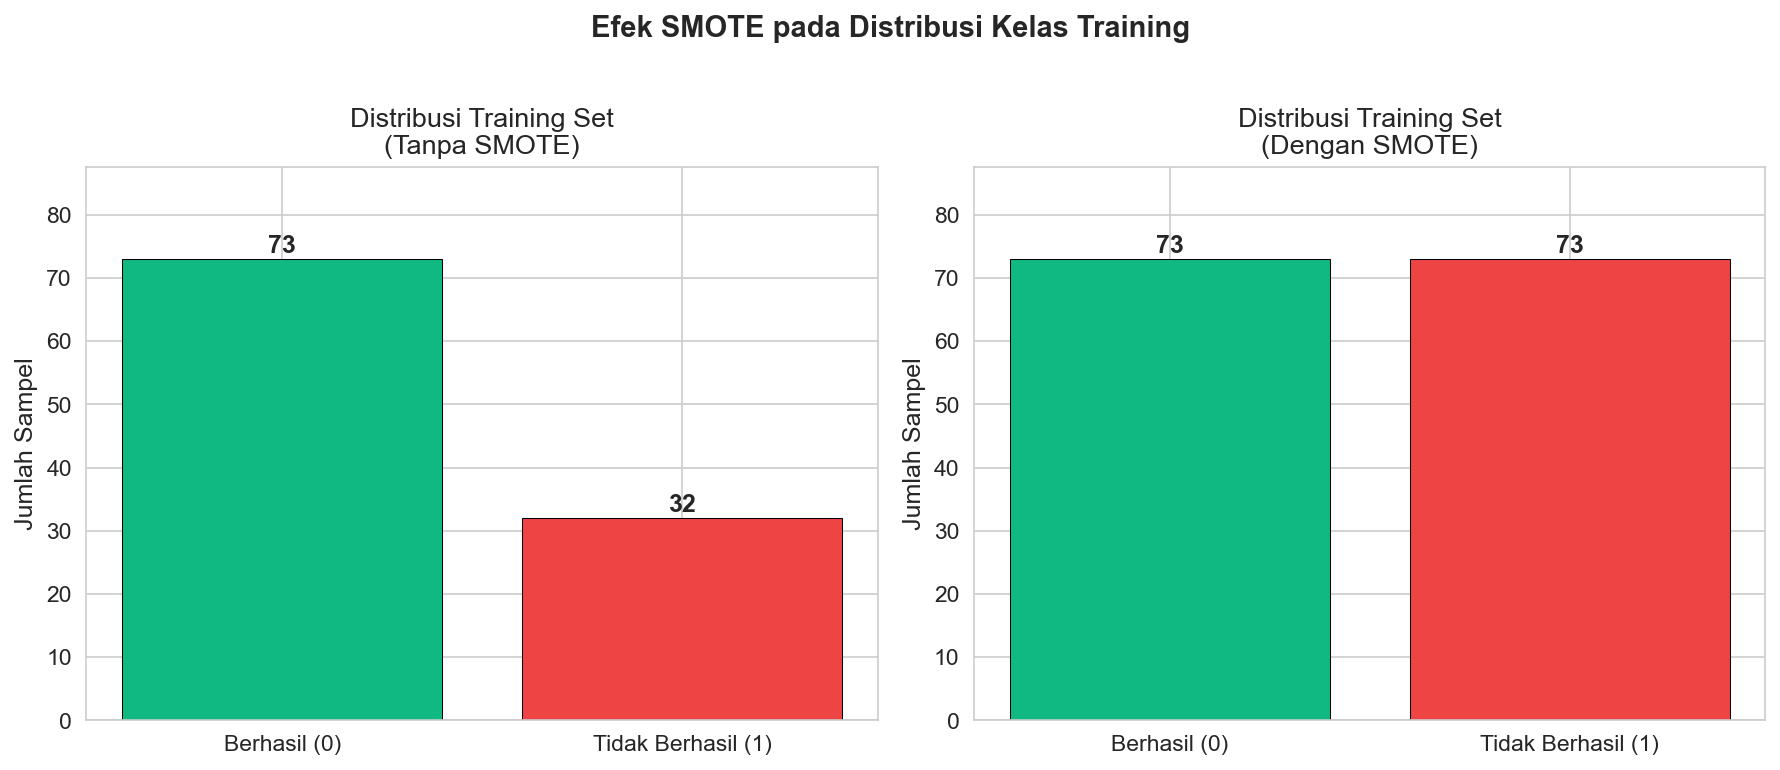

Tanpa SMOTE - Training: Kelas 0=73, Kelas 1=32, Total=105
Dengan SMOTE - Training: Kelas 0=73, Kelas 1=73, Total=146


In [6]:
# ============================
# 5b. Distribusi Kelas Training: Sebelum vs Sesudah SMOTE
# ============================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Tanpa SMOTE
y_train_ns_series = pd.Series(y_train_ns)
counts_ns = y_train_ns_series.value_counts().sort_index()
labels = ['Berhasil (0)', 'Tidak Berhasil (1)']
colors = ['#10b981', '#ef4444']

axes[0].bar(labels, counts_ns.values, color=colors, edgecolor='black', linewidth=0.5)
for i, v in enumerate(counts_ns.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Distribusi Training Set\n(Tanpa SMOTE)')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_ylim(0, max(counts_ns.values) * 1.2)

# Dengan SMOTE
y_train_sm_series = pd.Series(y_train_sm)
counts_sm = y_train_sm_series.value_counts().sort_index()

axes[1].bar(labels, counts_sm.values, color=colors, edgecolor='black', linewidth=0.5)
for i, v in enumerate(counts_sm.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Distribusi Training Set\n(Dengan SMOTE)')
axes[1].set_ylabel('Jumlah Sampel')
axes[1].set_ylim(0, max(counts_sm.values) * 1.2)

plt.suptitle('Efek SMOTE pada Distribusi Kelas Training', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'smote_class_distribution.png')
plt.savefig(FIGURES_DIR / 'smote_class_distribution.pdf')
plt.show()

print(f"Tanpa SMOTE - Training: Kelas 0={counts_ns.get(0,0)}, Kelas 1={counts_ns.get(1,0)}, Total={len(y_train_ns)}")
print(f"Dengan SMOTE - Training: Kelas 0={counts_sm.get(0,0)}, Kelas 1={counts_sm.get(1,0)}, Total={len(y_train_sm)}")

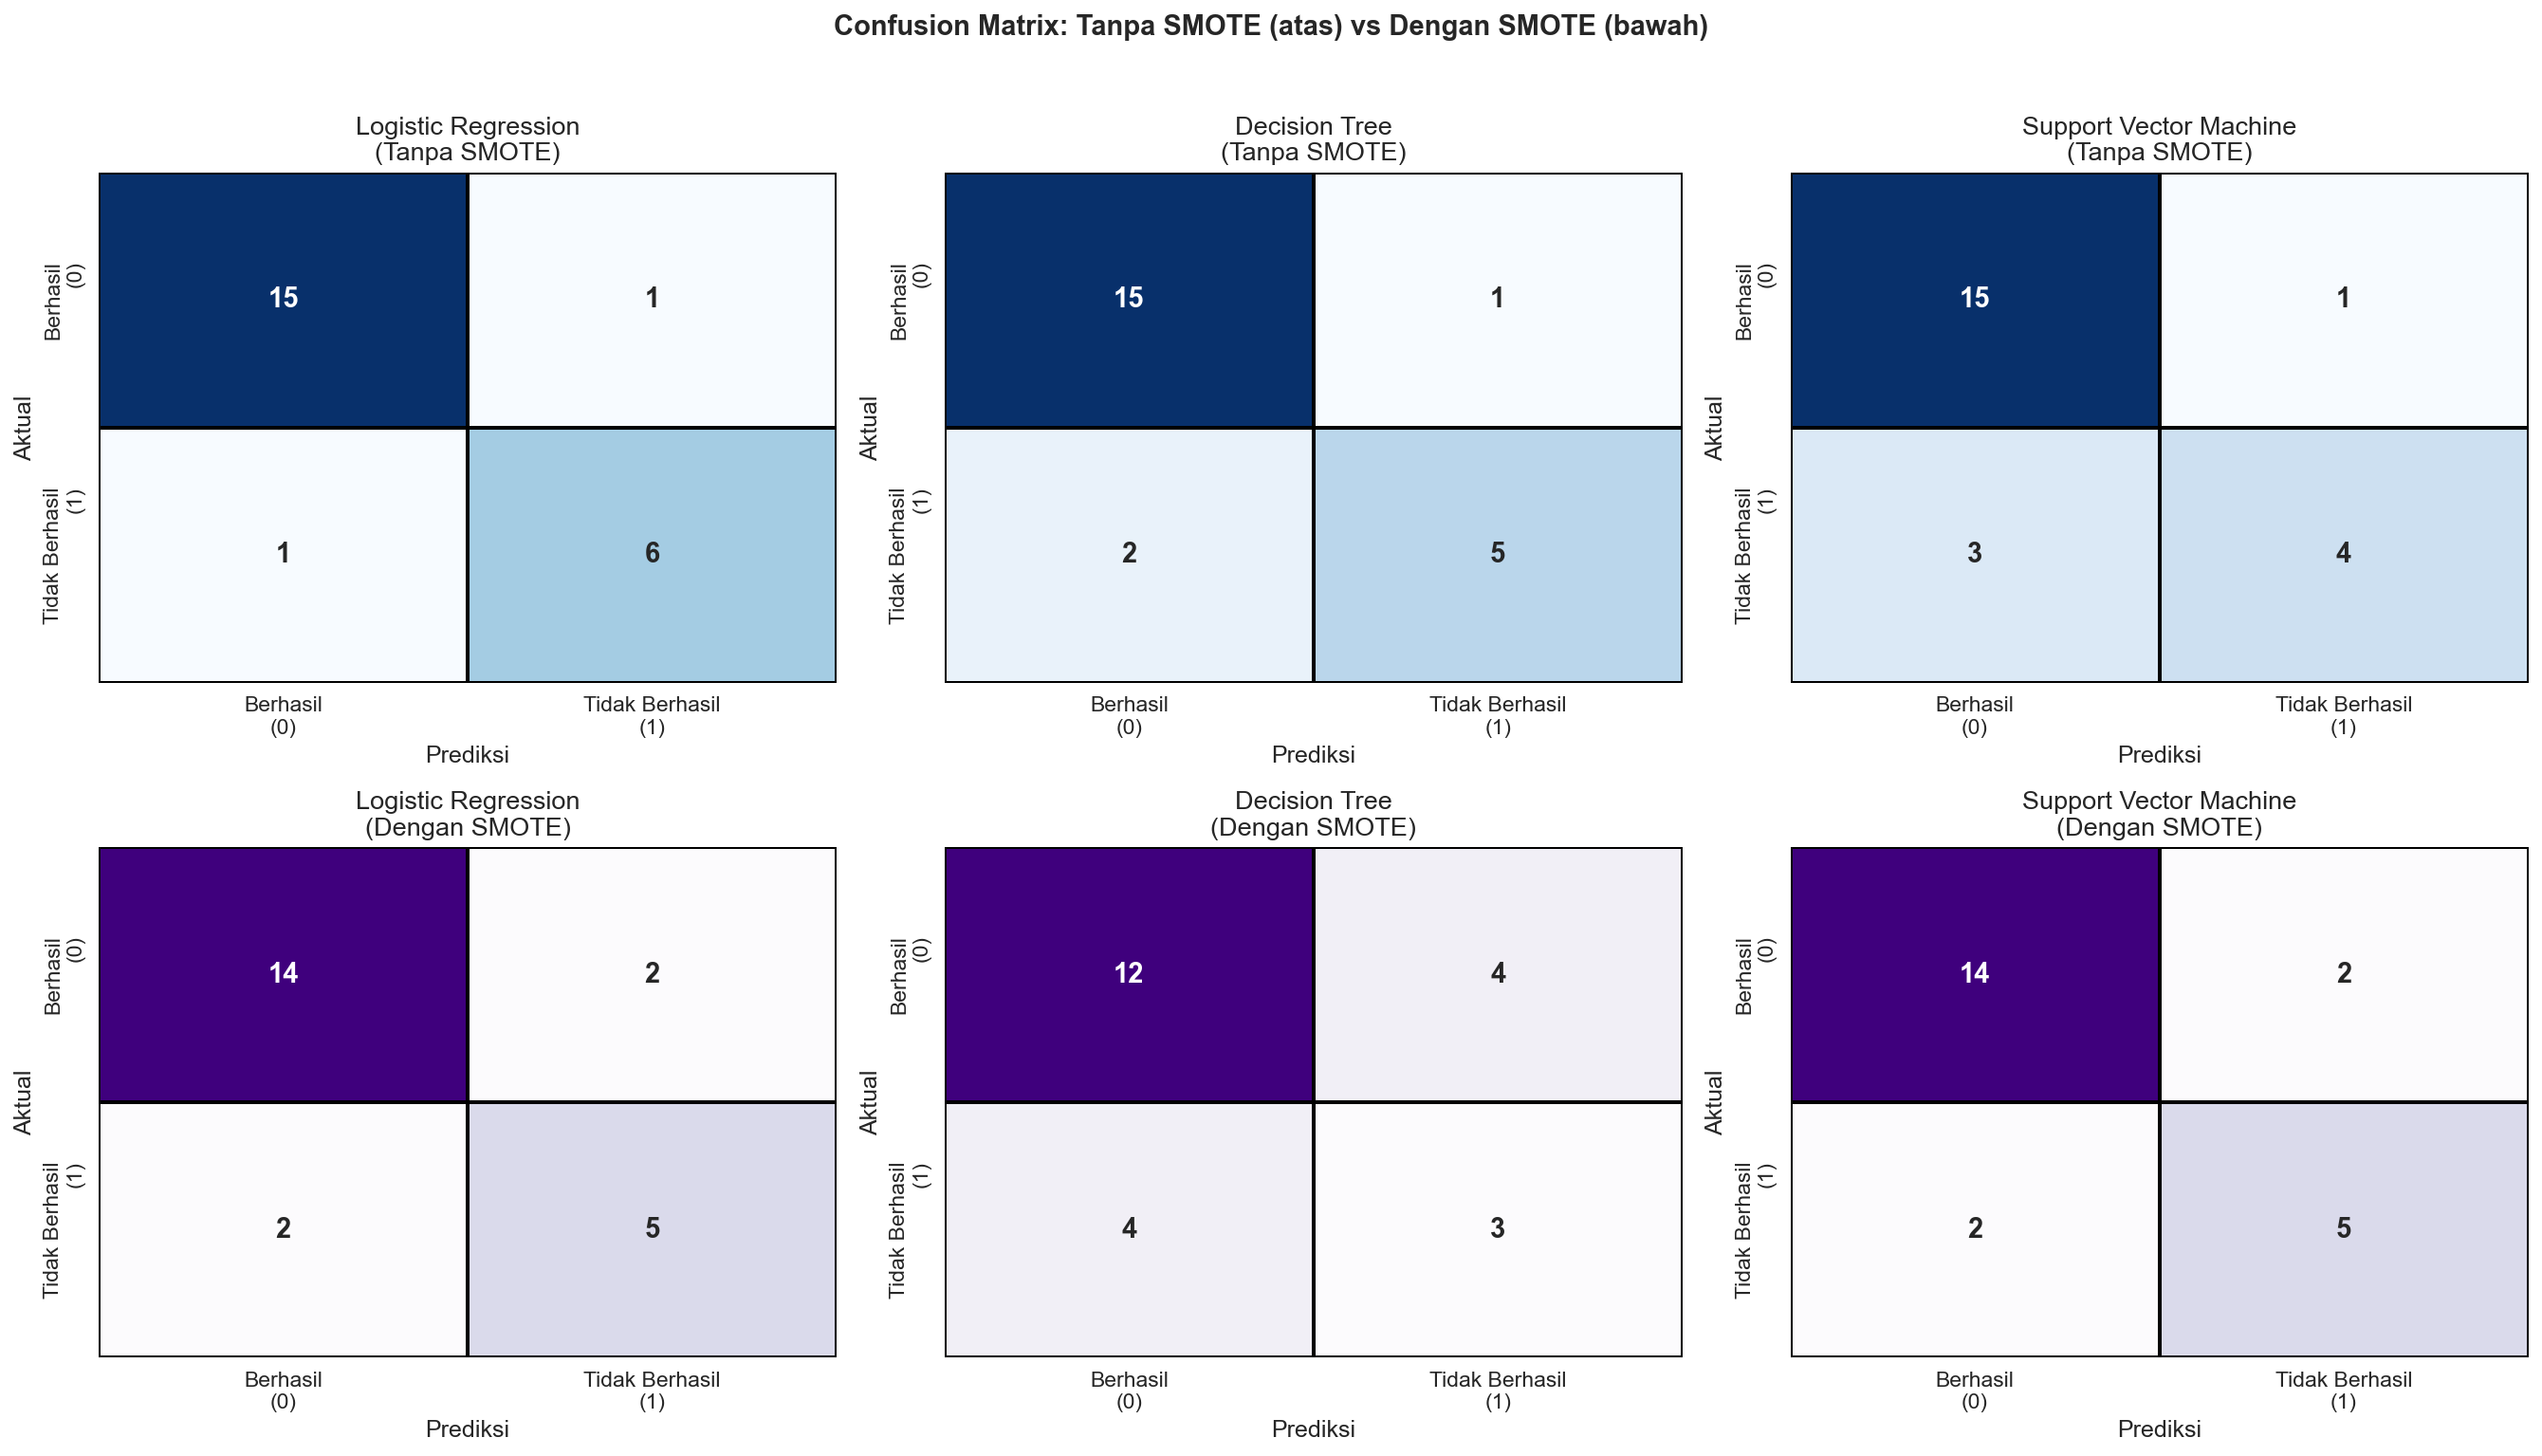

In [7]:
# ============================
# 5c. Confusion Matrix Perbandingan
# ============================
from sklearn.metrics import confusion_matrix as sk_confusion_matrix

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
labels_display = ['Berhasil\n(0)', 'Tidak Berhasil\n(1)']

for idx, model_name in enumerate(model_names):
    # Tanpa SMOTE (row 0)
    ax_ns = axes[0][idx]
    y_pred_ns = trainer_no_smote.models[model_name].predict(X_test_ns)
    cm_ns = sk_confusion_matrix(y_test_ns, y_pred_ns)
    sns.heatmap(cm_ns, annot=True, fmt='d', cmap='Blues', ax=ax_ns,
                xticklabels=labels_display, yticklabels=labels_display,
                linewidths=1, linecolor='black', cbar=False,
                annot_kws={'size': 14, 'weight': 'bold'})
    ax_ns.set_title(f'{model_name}\n(Tanpa SMOTE)')
    ax_ns.set_xlabel('Prediksi')
    ax_ns.set_ylabel('Aktual')

    # Dengan SMOTE (row 1)
    ax_sm = axes[1][idx]
    y_pred_sm = trainer_smote.models[model_name].predict(X_test_sm)
    cm_sm = sk_confusion_matrix(y_test_sm, y_pred_sm)
    sns.heatmap(cm_sm, annot=True, fmt='d', cmap='Purples', ax=ax_sm,
                xticklabels=labels_display, yticklabels=labels_display,
                linewidths=1, linecolor='black', cbar=False,
                annot_kws={'size': 14, 'weight': 'bold'})
    ax_sm.set_title(f'{model_name}\n(Dengan SMOTE)')
    ax_sm.set_xlabel('Prediksi')
    ax_sm.set_ylabel('Aktual')

plt.suptitle('Confusion Matrix: Tanpa SMOTE (atas) vs Dengan SMOTE (bawah)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'smote_confusion_matrices.png')
plt.savefig(FIGURES_DIR / 'smote_confusion_matrices.pdf')
plt.show()

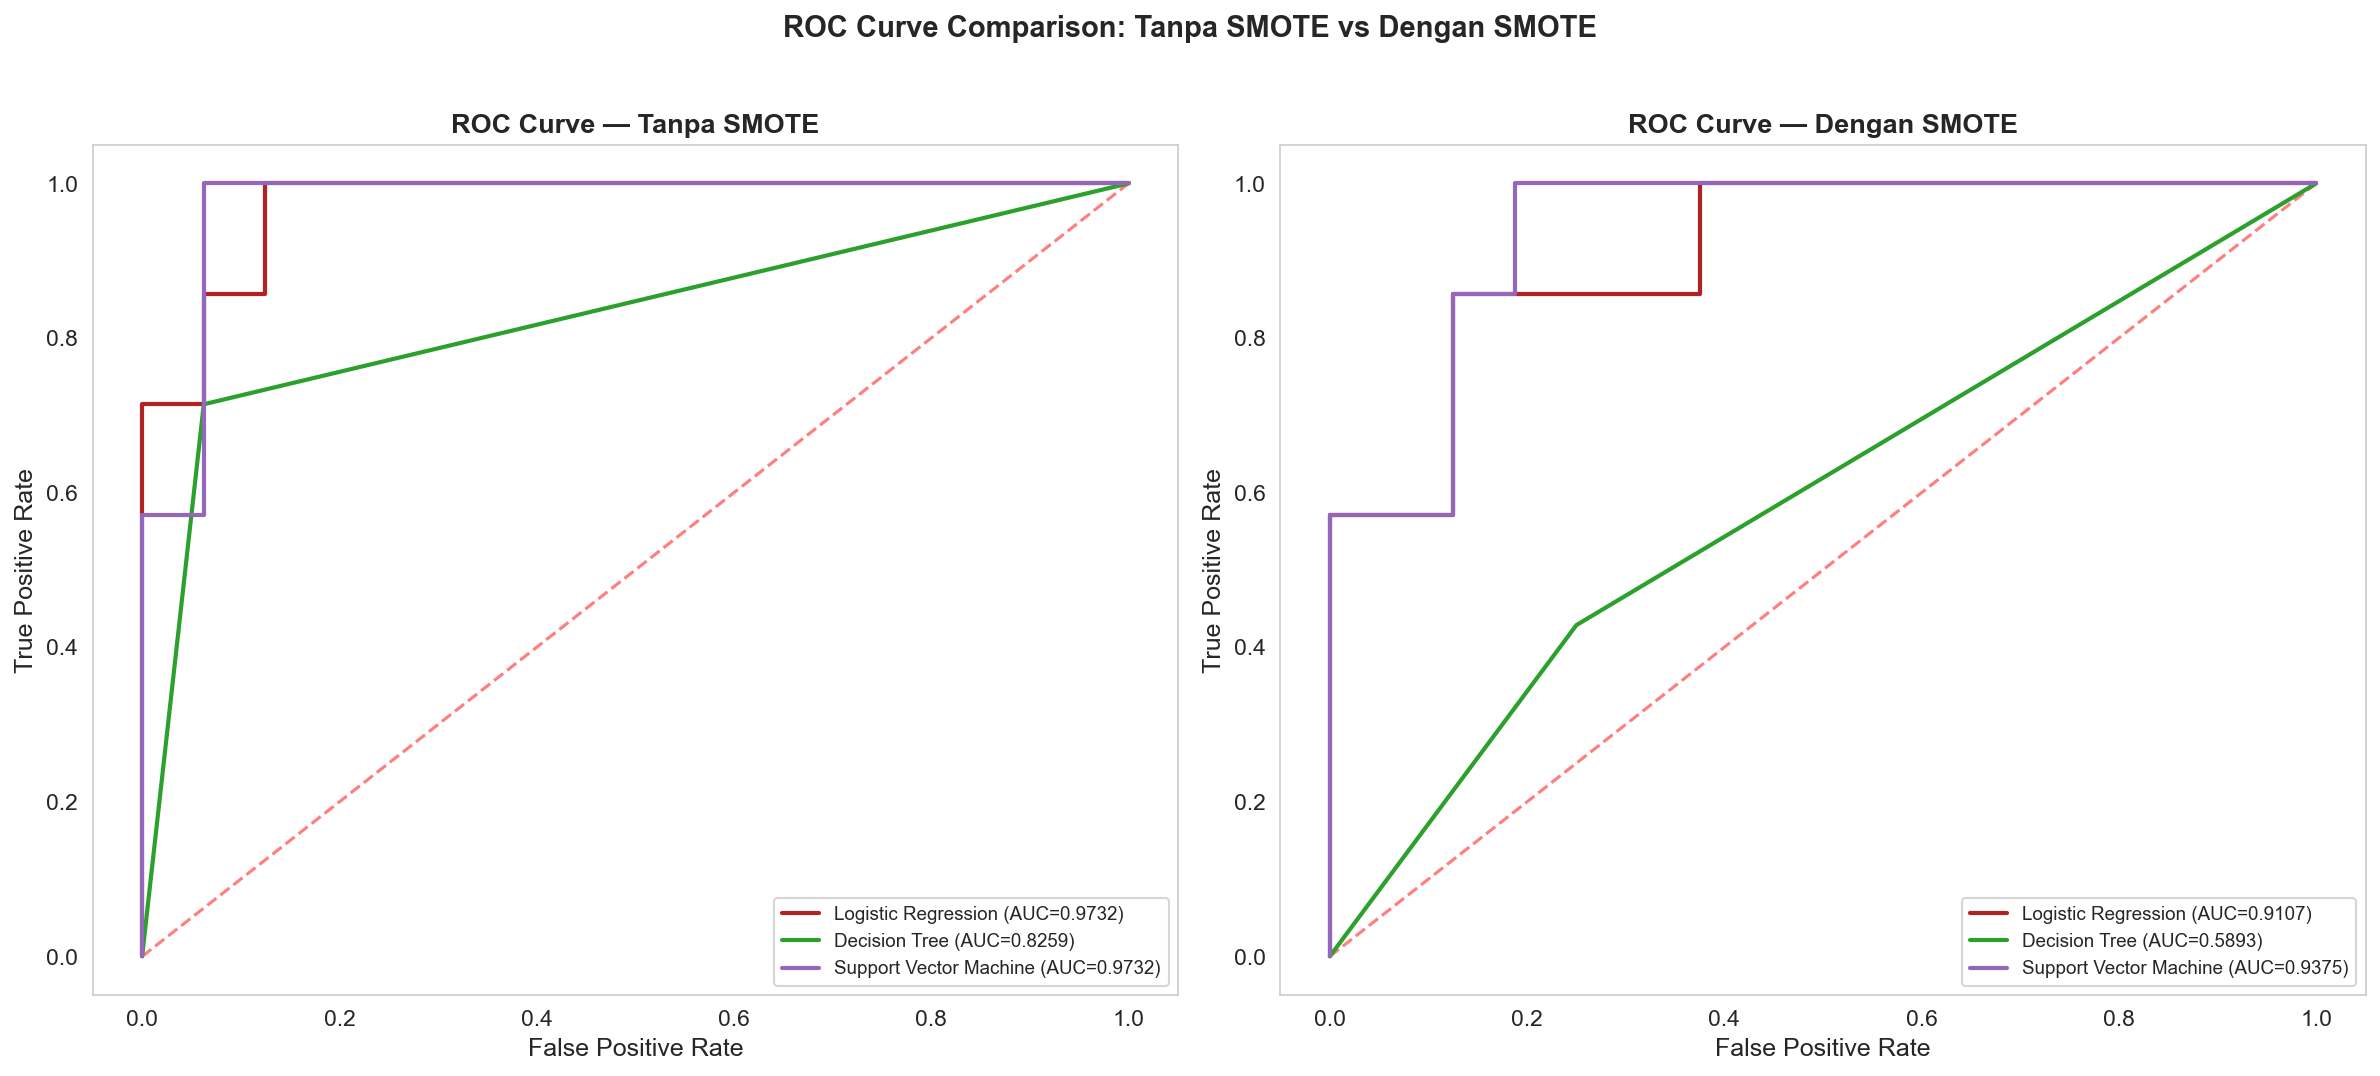

In [8]:
# ============================
# 5d. ROC Curve Perbandingan
# ============================
from sklearn.metrics import roc_curve, roc_auc_score

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
model_colors = {
    'Logistic Regression': '#b22222',
    'Decision Tree': '#2ca02c',
    'Support Vector Machine': '#9467bd'
}

# Tanpa SMOTE
ax = axes[0]
ax.plot([0, 1], [0, 1], 'r--', alpha=0.5)
for name, model in trainer_no_smote.models.items():
    y_proba = model.predict_proba(X_test_ns)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_ns, y_proba)
    auc = roc_auc_score(y_test_ns, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})',
            color=model_colors.get(name), linewidth=2)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve \u2014 Tanpa SMOTE', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(False)

# Dengan SMOTE
ax = axes[1]
ax.plot([0, 1], [0, 1], 'r--', alpha=0.5)
for name, model in trainer_smote.models.items():
    y_proba = model.predict_proba(X_test_sm)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_sm, y_proba)
    auc = roc_auc_score(y_test_sm, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})',
            color=model_colors.get(name), linewidth=2)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve \u2014 Dengan SMOTE', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(False)

plt.suptitle('ROC Curve Comparison: Tanpa SMOTE vs Dengan SMOTE',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'smote_roc_comparison.png')
plt.savefig(FIGURES_DIR / 'smote_roc_comparison.pdf')
plt.show()

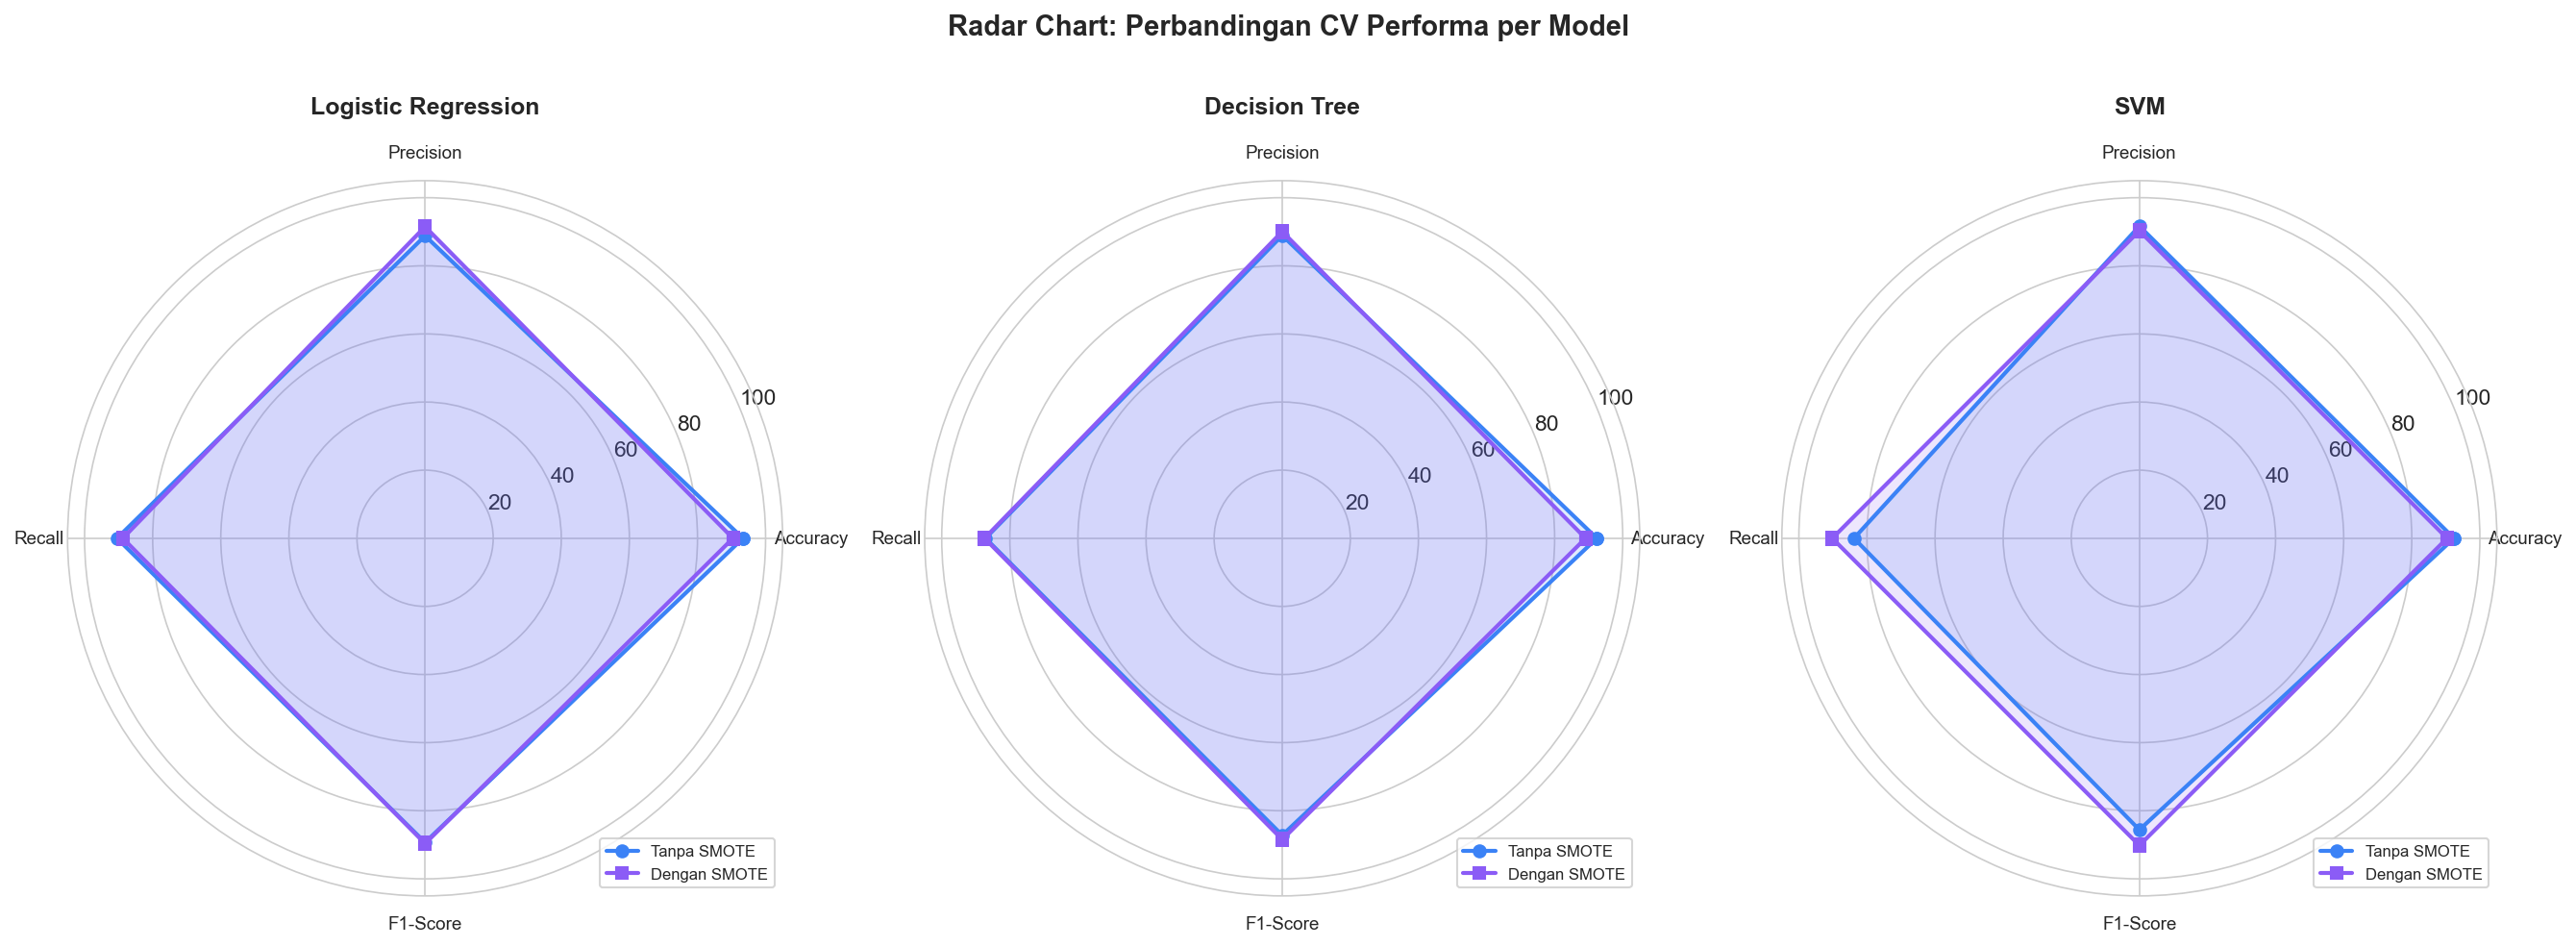

In [9]:
# ============================
# 5e. Radar Chart Perbandingan (Spider Plot) — Cross-Validation
# ============================
from matplotlib.patches import FancyBboxPatch

metrics_radar = ['accuracy', 'precision', 'recall', 'f1']
radar_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw=dict(polar=True))

angles = np.linspace(0, 2 * np.pi, len(metrics_radar), endpoint=False).tolist()
angles += angles[:1]

for idx, model_name in enumerate(model_names):
    ax = axes[idx]

    vals_ns = [cv_ns[model_name][m]['mean'] * 100 for m in metrics_radar]
    vals_ns += vals_ns[:1]
    vals_sm = [cv_sm[model_name][m]['mean'] * 100 for m in metrics_radar]
    vals_sm += vals_sm[:1]

    ax.plot(angles, vals_ns, 'o-', linewidth=2, label='Tanpa SMOTE', color='#3b82f6')
    ax.fill(angles, vals_ns, alpha=0.15, color='#3b82f6')
    ax.plot(angles, vals_sm, 's-', linewidth=2, label='Dengan SMOTE', color='#8b5cf6')
    ax.fill(angles, vals_sm, alpha=0.15, color='#8b5cf6')

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=9)
    ax.set_ylim(0, 105)
    ax.set_title(model_name.replace('Support Vector Machine', 'SVM'), fontsize=12, fontweight='bold', pad=15)
    ax.legend(loc='lower right', fontsize=8)

plt.suptitle('Radar Chart: Perbandingan CV Performa per Model', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'smote_radar_comparison.png')
plt.savefig(FIGURES_DIR / 'smote_radar_comparison.pdf')
plt.show()

## 6. Kesimpulan & Rekomendasi

In [10]:
# ============================
# 6. Kesimpulan Otomatis (berdasarkan Cross-Validation F1-Score)
# ============================
print("=" * 70)
print("  KESIMPULAN PERBANDINGAN SMOTE vs TANPA SMOTE")
print("  (Berdasarkan Cross-Validation F1-Score \u2014 sama seperti di web)")
print("=" * 70)

cv_ns = trainer_no_smote.cv_results
cv_sm = trainer_smote.cv_results

smote_wins = 0
no_smote_wins = 0
ties = 0

for model_name in model_names:
    f1_ns = cv_ns[model_name]['f1']['mean']
    f1_sm = cv_sm[model_name]['f1']['mean']
    diff = (f1_sm - f1_ns) * 100

    if abs(diff) < 0.5:
        status = "SAMA"
        ties += 1
    elif diff > 0:
        status = "SMOTE LEBIH BAIK"
        smote_wins += 1
    else:
        status = "TANPA SMOTE LEBIH BAIK"
        no_smote_wins += 1

    print(f"\n  {model_name}:")
    print(f"    CV F1 Tanpa SMOTE: {f1_ns*100:.2f}% (\u00b1{cv_ns[model_name]['f1']['std']*100:.2f}%)")
    print(f"    CV F1 Dengan SMOTE: {f1_sm*100:.2f}% (\u00b1{cv_sm[model_name]['f1']['std']*100:.2f}%)")
    print(f"    Selisih: {diff:+.2f} pp --> {status}")

print(f"\n{'='*70}")
print(f"  RINGKASAN:")
print(f"    SMOTE lebih baik pada {smote_wins} model")
print(f"    Tanpa SMOTE lebih baik pada {no_smote_wins} model")
print(f"    Hasil sama pada {ties} model")
print(f"{'='*70}")

# Rekomendasi otomatis
best_ns_name = max(cv_ns.keys(), key=lambda x: cv_ns[x]['f1']['mean'])
best_sm_name = max(cv_sm.keys(), key=lambda x: cv_sm[x]['f1']['mean'])
best_ns_f1 = cv_ns[best_ns_name]['f1']['mean']
best_sm_f1 = cv_sm[best_sm_name]['f1']['mean']

print(f"\n  REKOMENDASI:")
print(f"    Model terbaik TANPA SMOTE: {best_ns_name} (CV F1={best_ns_f1*100:.2f}%)")
print(f"    Model terbaik DENGAN SMOTE: {best_sm_name} (CV F1={best_sm_f1*100:.2f}%)")

if best_ns_f1 >= best_sm_f1:
    print(f"\n    >>> REKOMENDASI: Gunakan {best_ns_name} TANPA SMOTE")
    print(f"        Alasan: class_weight='balanced' sudah cukup menangani imbalance 2.28:1")
else:
    print(f"\n    >>> REKOMENDASI: Gunakan {best_sm_name} DENGAN SMOTE")
    print(f"        Alasan: SMOTE memberikan peningkatan F1-score yang signifikan")

print(f"\n  CATATAN untuk Disertasi:")
print(f"    - Rasio imbalance 2.28:1 tergolong ringan (mild)")
print(f"    - SMOTE lebih bermanfaat untuk imbalance > 5:1")
print(f"    - Untuk dataset kecil (n={len(X)}), SMOTE berisiko overfitting")
print(f"    - class_weight='balanced' adalah alternatif yang lebih konservatif")
print(f"    - Angka CV F1 ini konsisten dengan yang ditampilkan di web")

  KESIMPULAN PERBANDINGAN SMOTE vs TANPA SMOTE
  (Berdasarkan Cross-Validation F1-Score — sama seperti di web)

  Logistic Regression:
    CV F1 Tanpa SMOTE: 89.31% (±7.05%)
    CV F1 Dengan SMOTE: 89.66% (±7.61%)
    Selisih: +0.35 pp --> SAMA

  Decision Tree:
    CV F1 Tanpa SMOTE: 87.19% (±8.50%)
    CV F1 Dengan SMOTE: 88.46% (±8.23%)
    Selisih: +1.26 pp --> SMOTE LEBIH BAIK

  Support Vector Machine:
    CV F1 Tanpa SMOTE: 85.60% (±11.10%)
    CV F1 Dengan SMOTE: 90.19% (±7.05%)
    Selisih: +4.58 pp --> SMOTE LEBIH BAIK

  RINGKASAN:
    SMOTE lebih baik pada 2 model
    Tanpa SMOTE lebih baik pada 0 model
    Hasil sama pada 1 model

  REKOMENDASI:
    Model terbaik TANPA SMOTE: Logistic Regression (CV F1=89.31%)
    Model terbaik DENGAN SMOTE: Support Vector Machine (CV F1=90.19%)

    >>> REKOMENDASI: Gunakan Support Vector Machine DENGAN SMOTE
        Alasan: SMOTE memberikan peningkatan F1-score yang signifikan

  CATATAN untuk Disertasi:
    - Rasio imbalance 2.28:1 terg

# Perbandingan Model: Tanpa SMOTE vs Dengan SMOTE
## Analisis Dampak SMOTE terhadap Performa Model Prediksi MDR-TB

**Tujuan:** Membandingkan performa tiga model (Logistic Regression, Decision Tree, SVM) ketika dilatih **tanpa SMOTE** vs **dengan SMOTE** pada dataset MDR-TB.

**SMOTE (Synthetic Minority Over-sampling Technique)** menghasilkan data sintetis untuk kelas minoritas sehingga distribusi kelas menjadi seimbang pada data training.

**Sections:**
1. Setup & Data Loading
2. Training Tanpa SMOTE
3. Training Dengan SMOTE
4. Perbandingan Hasil
5. Visualisasi Perbandingan
6. Kesimpulan & Rekomendasi